In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
count_dataset_A = 1000
count_dataset_B = 1000

df_full = pd.read_csv(r"C:\Users\makumarm\Documents\ResearchWork\EdgeAI_IISC\Project\Hackthon\guardian-edge\riding_20260103_165255.csv")
df_full.head()
# df_A = pd.read_csv(r"C:\Users\24ani\Documents\ACM School\Data Collection\imu_data\animesh\jogging_20251228_183925.csv")
# df_B = pd.read_csv(r"C:\Users\24ani\Documents\ACM School\Data Collection\imu_data\animesh\jogging_20251228_183925.csv")

# seperate the df based on device type
df_A = df_full.iloc[:count_dataset_A, :]

In [3]:
# Separate the df based on device type
df_A = df_full[df_full['Device'] == 'A'].reset_index(drop=True)
df_B = df_full[df_full['Device'] == 'B'].reset_index(drop=True)

print(f"Device A samples: {len(df_A)}")
print(f"Device B samples: {len(df_B)}")
print(df_A)

Device A samples: 5957
Device B samples: 5992
     Device  timestamp        ax        ay        az        gx        gy  \
0         A     583802 -0.979126  0.207031  0.002808 -0.488281 -1.403809   
1         A     583822 -0.979492  0.203247  0.003784 -0.122070 -1.464844   
2         A     583842 -0.981079  0.201538  0.002686 -0.549316 -1.342773   
3         A     583862 -0.978149  0.208984  0.003174 -0.427246 -1.403809   
4         A     583882 -0.979736  0.207764  0.000122 -0.122070 -1.464844   
...     ...        ...       ...       ...       ...       ...       ...   
5952      A     703710 -0.977417  0.218262 -0.010986 -0.427246 -1.892090   
5953      A     703730 -0.977661  0.220459 -0.016479  0.061035 -2.075195   
5954      A     703750 -0.977051  0.223999 -0.016113 -0.671387 -2.075195   
5955      A     703770 -0.973755  0.240112 -0.011230 -1.098633 -2.197266   
5956      A     703790 -0.971436  0.252808 -0.003906 -0.244141 -2.380371   

            gz activity  
0    -1.159668 

In [4]:
# Check unique device types
print("Device types and their counts:")
print(df_full['Device'].value_counts())
print(f"\nUnique devices: {df_full['Device'].unique()}")

Device types and their counts:
Device
B    5992
A    5957
Name: count, dtype: int64

Unique devices: ['A' 'B']


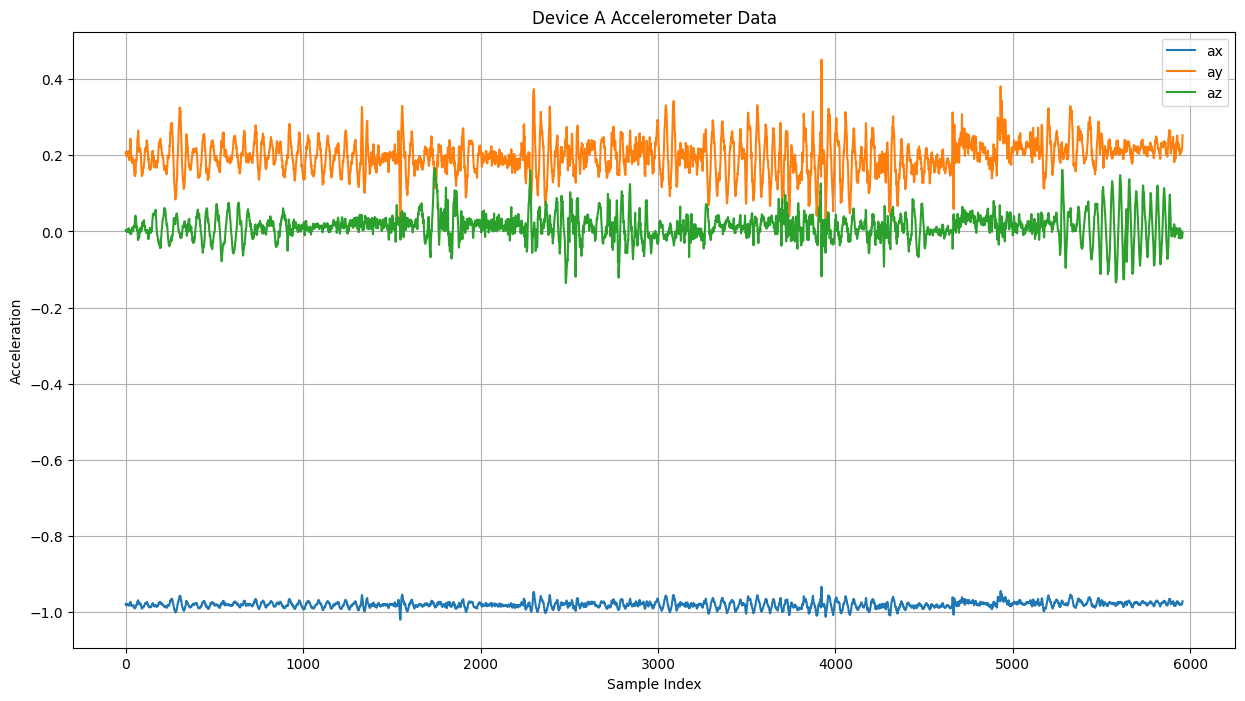

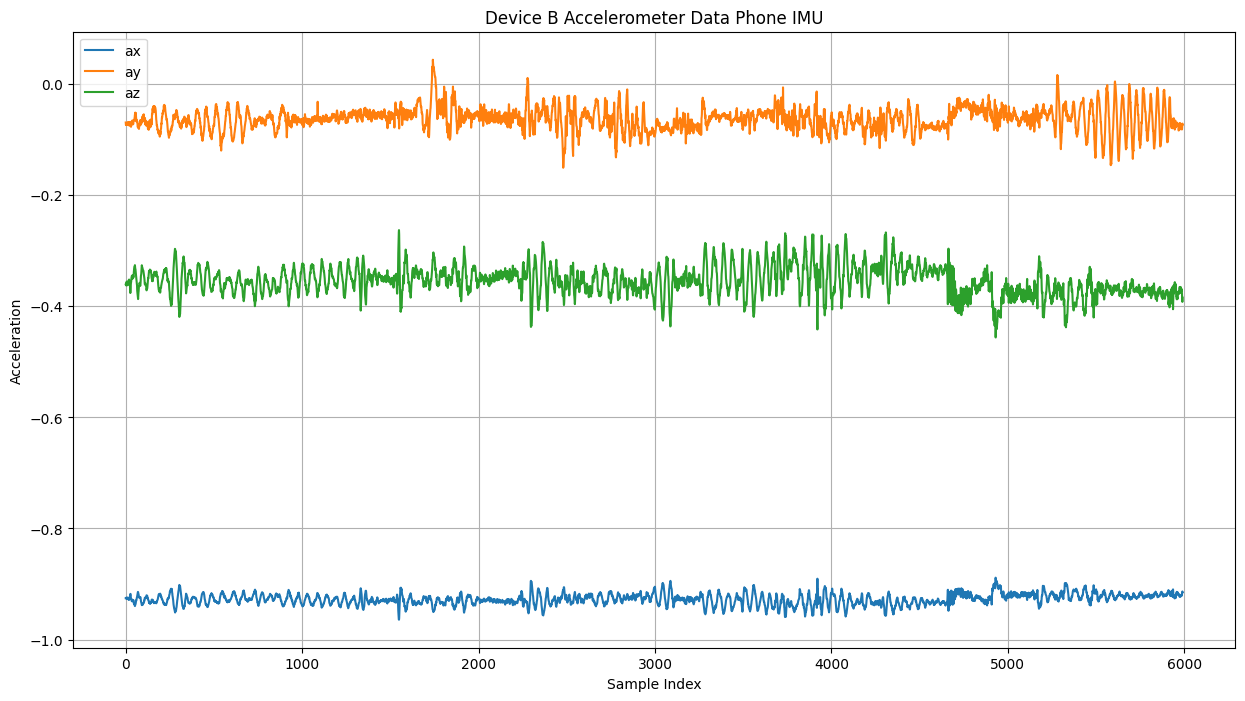

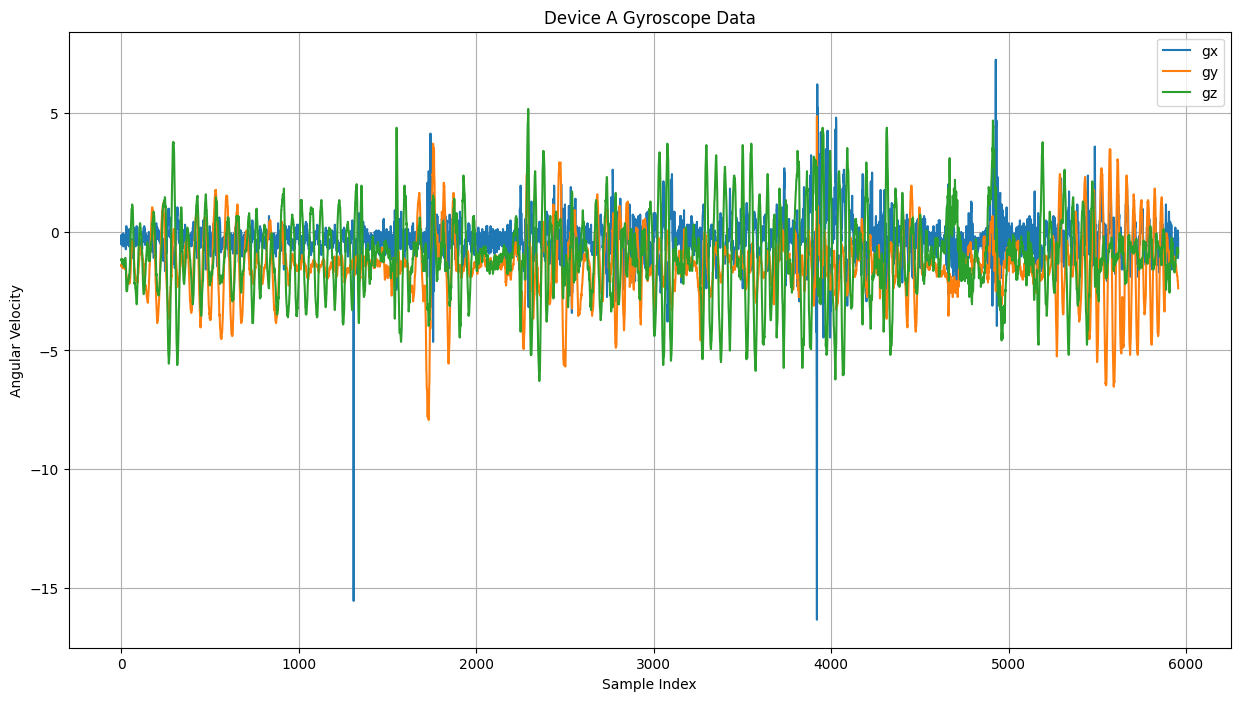

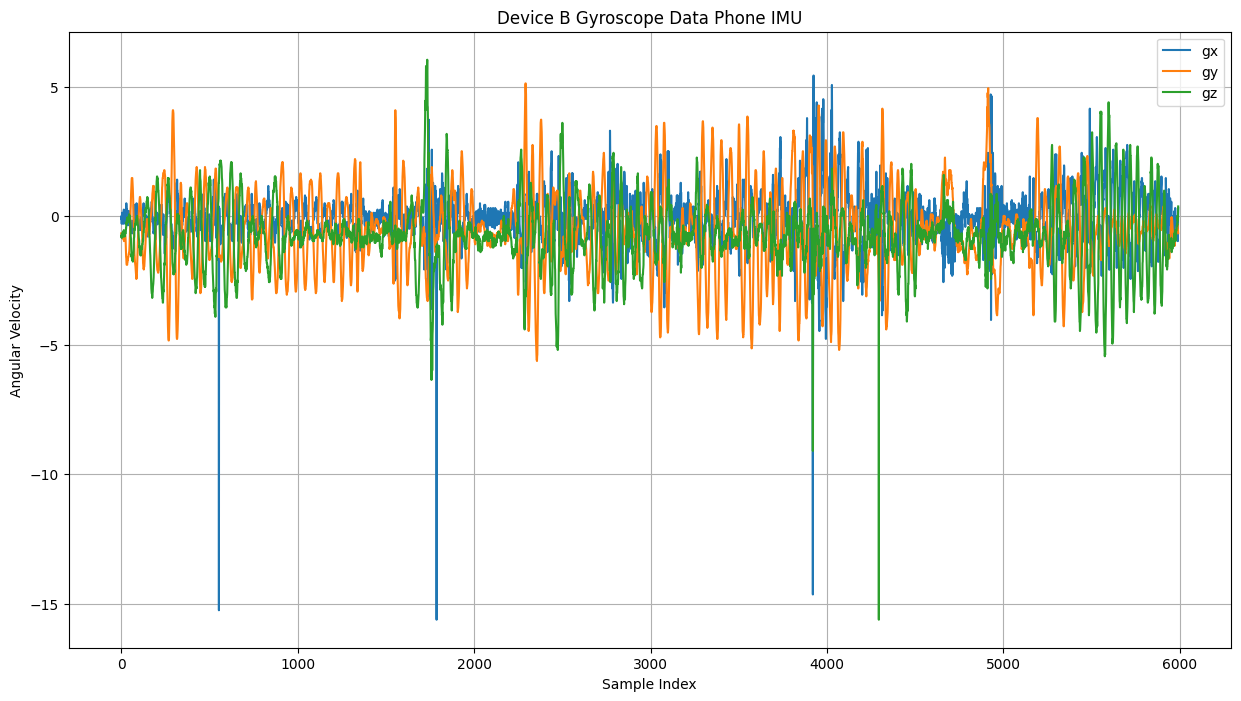

In [5]:
# plot the ax, ay, az for device A
plt.figure(figsize=(15, 8))
plt.plot(df_A['ax'], label='ax')
plt.plot(df_A['ay'], label='ay')
plt.plot(df_A['az'], label='az')
plt.title('Device A Accelerometer Data')
plt.xlabel('Sample Index')
plt.ylabel('Acceleration')
plt.legend()
plt.grid()
plt.show()

# plot the ax, ay, az for device B
plt.figure(figsize=(15, 8))
plt.plot(df_B['ax'], label='ax')
plt.plot(df_B['ay'], label='ay')
plt.plot(df_B['az'], label='az')
plt.title('Device B Accelerometer Data Phone IMU')
plt.xlabel('Sample Index')
plt.ylabel('Acceleration')
plt.legend()
plt.grid()
plt.show()

# plot the gx, gy, gz for device A
plt.figure(figsize=(15, 8))
plt.plot(df_A['gx'], label='gx')
plt.plot(df_A['gy'], label='gy')
plt.plot(df_A['gz'], label='gz')
plt.title('Device A Gyroscope Data')
plt.xlabel('Sample Index')
plt.ylabel('Angular Velocity')
plt.legend()
plt.grid()
plt.show()

# plot the gx, gy, gz for device B
plt.figure(figsize=(15, 8))
plt.plot(df_B['gx'], label='gx')
plt.plot(df_B['gy'], label='gy')
plt.plot(df_B['gz'], label='gz')
plt.title('Device B Gyroscope Data Phone IMU')
plt.xlabel('Sample Index')
plt.ylabel('Angular Velocity')
plt.legend()
plt.grid()
plt.show()


In [6]:
# Create sliding window dataframe from df_A
# Window size: 200 samples per entry
# Target: < 120 divisions

window_size = 200
total_samples = len(df_A)

# Calculate step size to get approximately <120 divisions
target_divisions = 116
step_size = (total_samples - window_size) // (target_divisions - 1)

print(f"Total samples in df_A: {total_samples}")
print(f"Window size: {window_size}")
print(f"Step size: {step_size}")

# Create sliding windows
windows = []
for i in range(0, total_samples - window_size + 1, step_size):
    window = df_A.iloc[i:i+window_size].copy()
    windows.append(window)
    
print(f"Number of windows created: {len(windows)}")

# Create a list to store each window's data
windowed_data = []
for idx, window in enumerate(windows):
    # Create a dictionary with window metadata and flattened sensor data
    window_dict = {
        'window_id': idx,
        'start_idx': idx * step_size,
        'end_idx': idx * step_size + window_size - 1,
    }
    
    # Add flattened sensor readings
    for col in ['ax', 'ay', 'az', 'gx', 'gy', 'gz']:
        for i, val in enumerate(window[col].values):
            window_dict[f'{col}_{i}'] = val
    
    windowed_data.append(window_dict)

# Create the new dataframe
df_A_windowed = pd.DataFrame(windowed_data)

print(f"\nWindowed dataframe shape: {df_A_windowed.shape}")
print(f"Columns: window_id, start_idx, end_idx, + {6 * window_size} sensor readings")
df_A_windowed.head()

Total samples in df_A: 5957
Window size: 200
Step size: 50
Number of windows created: 116

Windowed dataframe shape: (116, 1203)
Columns: window_id, start_idx, end_idx, + 1200 sensor readings


,window_id,start_idx,end_idx,ax_0,ax_1,ax_2,ax_3,ax_4,ax_5,ax_6,...,gz_190,gz_191,gz_192,gz_193,gz_194,gz_195,gz_196,gz_197,gz_198,gz_199
0,0,0,199,-0.979126,-0.979492,-0.981079,-0.978149,-0.979736,-0.981079,-0.982300,...,-0.305176,-0.488281,-0.732422,-1.037598,-0.976563,-1.403809,-1.586915,-1.831055,-1.770020,-1.953125
1,1,50,249,-0.990234,-0.989258,-0.989014,-0.989746,-0.987793,-0.987671,-0.985718,...,1.281738,1.159668,1.281738,1.342773,1.281738,1.464844,1.464844,1.220703,1.037598,1.098633
2,2,100,299,-0.985718,-0.985962,-0.985107,-0.983765,-0.984497,-0.982422,-0.980103,...,3.662110,3.784181,3.723145,3.723145,3.784181,3.723145,3.540040,3.356935,2.929688,2.502441
3,3,150,349,-0.977661,-0.979248,-0.977905,-0.976685,-0.978638,-0.980713,-0.980225,...,0.854492,0.427246,-0.122070,-0.488281,-0.732422,-0.854492,-1.159668,-1.525879,-1.647950,-1.770020
4,4,200,399,-0.975830,-0.976563,-0.979004,-0.978882,-0.980103,-0.978760,-0.978149,...,-1.464844,-1.525879,-1.647950,-1.831055,-1.953125,-2.014160,-2.136230,-2.319336,-2.441406,-2.624512


In [ ]:
# Create 3D array: (num_windows, window_size, num_sensors)
# Shape: (116, 200, 6)
# Dimensions: [window_id, time_step, sensor_channel]

sensor_columns = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']
num_windows = len(windows)
num_sensors = len(sensor_columns)

# Initialize 3D array
data_3d = np.zeros((num_windows, window_size, num_sensors))

# Fill the 3D array
for window_idx, window in enumerate(windows):
    for sensor_idx, sensor in enumerate(sensor_columns):
        data_3d[window_idx, :, sensor_idx] = window[sensor].values

print(f"3D array shape: {data_3d.shape}")
print(f"Dimensions: (num_windows={num_windows}, window_size={window_size}, num_sensors={num_sensors})")
print(f"\nArray details:")
print(f"  - Axis 0 (windows/channels): {data_3d.shape[0]} windows")
print(f"  - Axis 1 (time steps/rows): {data_3d.shape[1]} samples per window")
print(f"  - Axis 2 (sensor columns): {data_3d.shape[2]} sensors {sensor_columns}")
print(f"\nFirst window, first 5 time steps:")
print(pd.DataFrame(data_3d[0, :5, :], columns=sensor_columns))

3D array shape: (116, 200, 6)
Dimensions: (num_windows=116, window_size=200, num_sensors=6)

Array details:
  - Axis 0 (windows/channels): 116 windows
  - Axis 1 (time steps/rows): 200 samples per window
  - Axis 2 (sensor columns): 6 sensors ['ax', 'ay', 'az', 'gx', 'gy', 'gz']

First window, first 5 time steps:
         ax        ay        az        gx        gy        gz
0 -0.979126  0.207031  0.002808 -0.488281 -1.403809 -1.159668
1 -0.979492  0.203247  0.003784 -0.122070 -1.464844 -1.220703
2 -0.981079  0.201538  0.002686 -0.549316 -1.342773 -1.159668
3 -0.978149  0.208984  0.003174 -0.427246 -1.403809 -1.159668
4 -0.979736  0.207764  0.000122 -0.122070 -1.464844 -1.342773


In [8]:
# Calculate statistical features for each window and each sensor
# For each of the 116 windows, compute statistics across the 200 time steps

# Initialize dictionary to store statistics
stats_dict = {
    'window_id': []
}

# Define statistical functions to compute
stat_functions = {
    'mean': np.mean,
    'std': np.std,
    'min': np.min,
    'max': np.max,
    'median': np.median,
    'q25': lambda x: np.percentile(x, 25),
    'q75': lambda x: np.percentile(x, 75)
}

# Initialize columns for each sensor and statistic
for sensor in sensor_columns:
    for stat_name in stat_functions.keys():
        stats_dict[f'{sensor}_{stat_name}'] = []

# Compute statistics for each window
for window_idx in range(num_windows):
    stats_dict['window_id'].append(window_idx)
    
    # For each sensor
    for sensor_idx, sensor in enumerate(sensor_columns):
        # Extract the time series for this window and sensor
        time_series = data_3d[window_idx, :, sensor_idx]
        
        # Compute each statistic
        for stat_name, stat_func in stat_functions.items():
            value = stat_func(time_series)
            stats_dict[f'{sensor}_{stat_name}'].append(value)

# Create DataFrame with statistics
df_stats = pd.DataFrame(stats_dict)

print(f"Statistics DataFrame shape: {df_stats.shape}")
print(f"Rows: {df_stats.shape[0]} windows")
print(f"Columns: {df_stats.shape[1]} features (window_id + {len(sensor_columns)} sensors × {len(stat_functions)} statistics)")
print(f"\nColumn names:")
print(df_stats.columns.tolist())
print(f"\nFirst 5 windows statistics:")
df_stats.head()

Statistics DataFrame shape: (116, 43)
Rows: 116 windows
Columns: 43 features (window_id + 6 sensors × 7 statistics)

Column names:
['window_id', 'ax_mean', 'ax_std', 'ax_min', 'ax_max', 'ax_median', 'ax_q25', 'ax_q75', 'ay_mean', 'ay_std', 'ay_min', 'ay_max', 'ay_median', 'ay_q25', 'ay_q75', 'az_mean', 'az_std', 'az_min', 'az_max', 'az_median', 'az_q25', 'az_q75', 'gx_mean', 'gx_std', 'gx_min', 'gx_max', 'gx_median', 'gx_q25', 'gx_q75', 'gy_mean', 'gy_std', 'gy_min', 'gy_max', 'gy_median', 'gy_q25', 'gy_q75', 'gz_mean', 'gz_std', 'gz_min', 'gz_max', 'gz_median', 'gz_q25', 'gz_q75']

First 5 windows statistics:


,window_id,ax_mean,ax_std,ax_min,ax_max,ax_median,ax_q25,ax_q75,ay_mean,ay_std,...,gy_median,gy_q25,gy_q75,gz_mean,gz_std,gz_min,gz_max,gz_median,gz_q25,gz_q75
0,0,-0.981143,0.004576,-0.990234,-0.968750,-0.981445,-0.984406,-0.977905,0.195686,0.026063,...,-1.525879,-2.014160,-0.854492,-1.048889,1.041827,-3.051759,1.159668,-1.159668,-1.846314,-0.350952
1,1,-0.981490,0.004612,-0.990234,-0.968750,-0.982056,-0.985107,-0.977905,0.192848,0.026944,...,-1.220703,-2.090454,-0.427246,-0.809937,1.244529,-3.051759,1.464844,-0.793457,-1.907349,0.198365
2,2,-0.981364,0.006930,-1.000977,-0.964844,-0.982056,-0.985137,-0.977051,0.192634,0.039836,...,-1.312256,-2.502441,-0.289917,-0.788269,1.921355,-5.554201,3.784181,-0.732422,-1.998901,0.366211
3,3,-0.980444,0.009162,-1.000977,-0.957031,-0.981506,-0.985260,-0.975616,0.196967,0.051688,...,-1.373291,-2.319336,-0.122070,-0.977478,2.242089,-5.615236,3.784181,-0.823975,-2.441406,0.671387
4,4,-0.980717,0.009173,-1.000977,-0.957031,-0.981445,-0.986206,-0.976318,0.196015,0.051357,...,-1.464844,-2.441406,-0.549316,-1.141357,2.228736,-5.615236,3.784181,-1.159668,-2.441406,0.381470


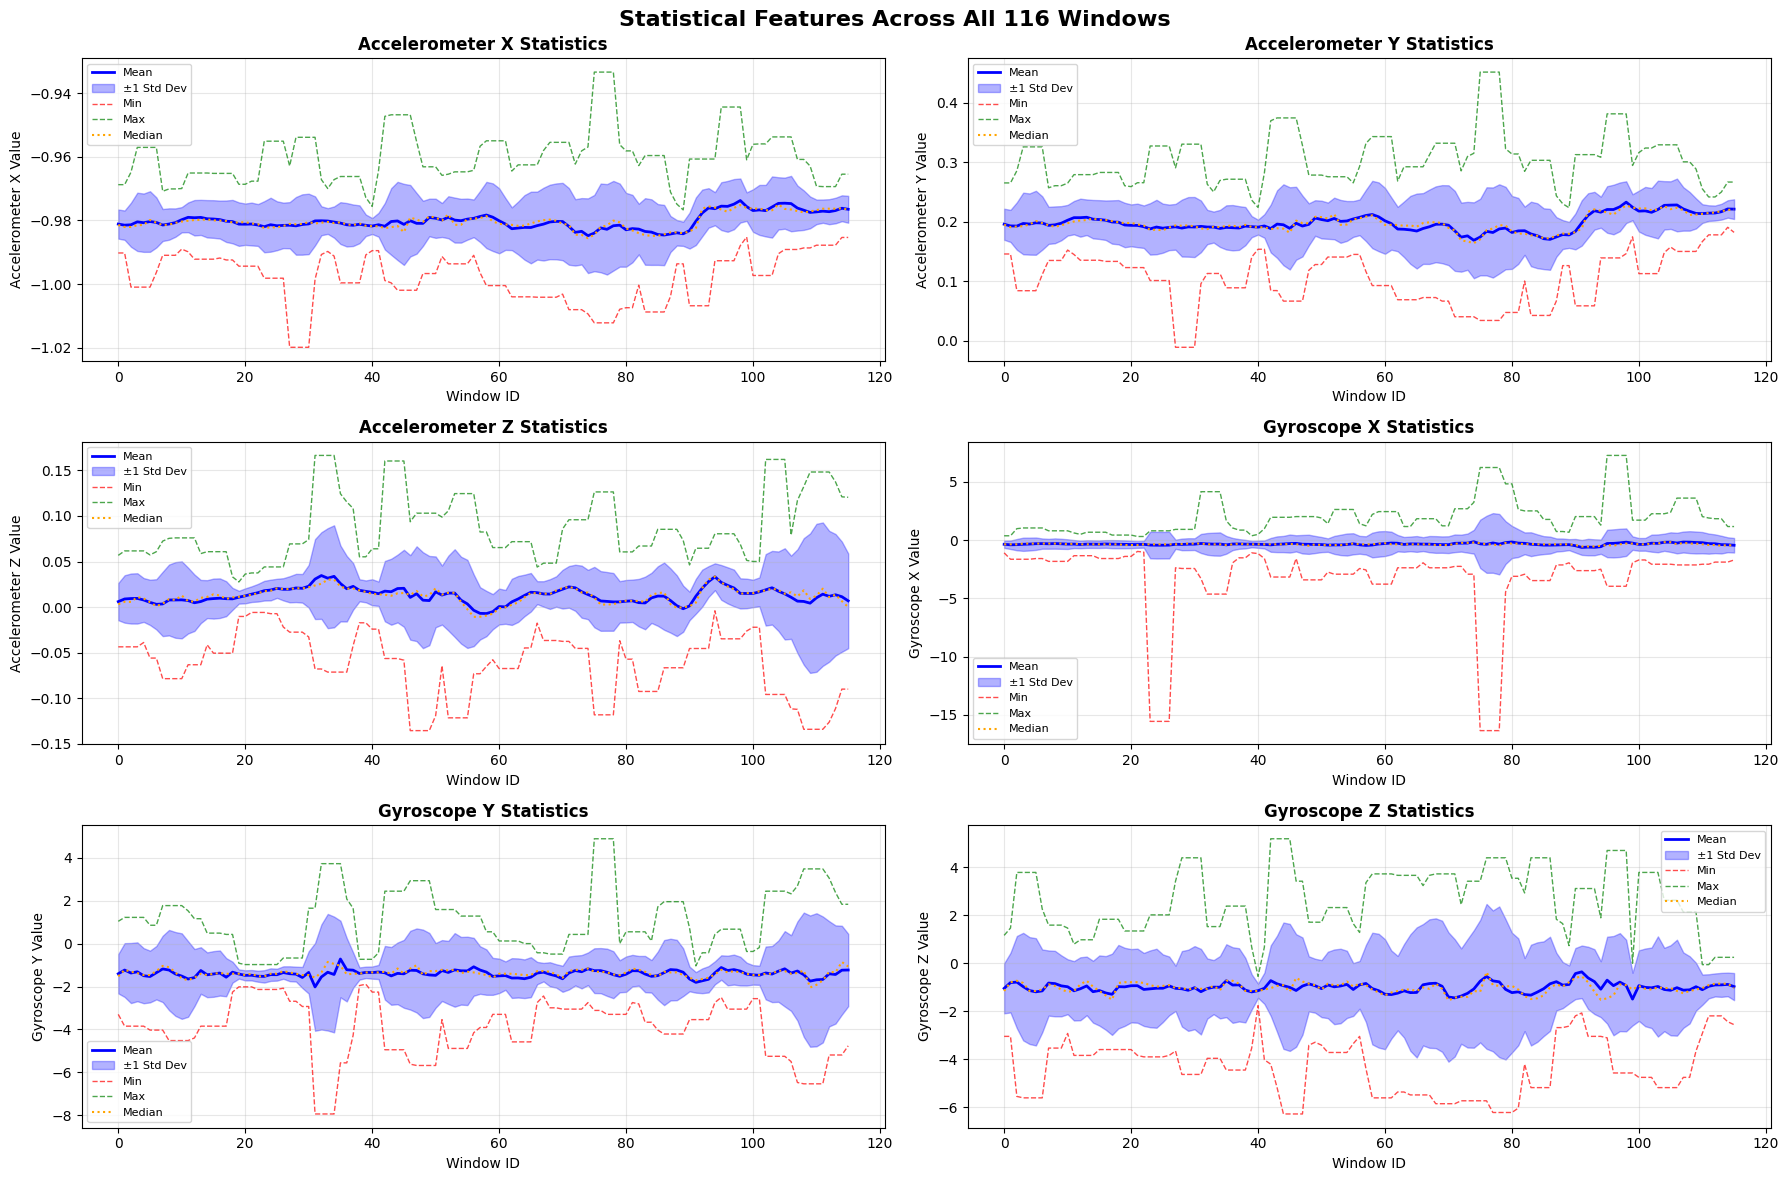

In [9]:
# Plot statistical data for all sensors across all windows
fig, axes = plt.subplots(3, 2, figsize=(18, 12))
fig.suptitle('Statistical Features Across All 116 Windows', fontsize=16, fontweight='bold')

sensors = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']
sensor_labels = ['Accelerometer X', 'Accelerometer Y', 'Accelerometer Z', 
                 'Gyroscope X', 'Gyroscope Y', 'Gyroscope Z']

for idx, (sensor, label) in enumerate(zip(sensors, sensor_labels)):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    # Plot mean with std as shaded area
    ax.plot(df_stats['window_id'], df_stats[f'{sensor}_mean'], 
            label='Mean', linewidth=2, color='blue')
    ax.fill_between(df_stats['window_id'], 
                     df_stats[f'{sensor}_mean'] - df_stats[f'{sensor}_std'],
                     df_stats[f'{sensor}_mean'] + df_stats[f'{sensor}_std'],
                     alpha=0.3, color='blue', label='±1 Std Dev')
    
    # Plot min and max
    ax.plot(df_stats['window_id'], df_stats[f'{sensor}_min'], 
            label='Min', linewidth=1, linestyle='--', color='red', alpha=0.7)
    ax.plot(df_stats['window_id'], df_stats[f'{sensor}_max'], 
            label='Max', linewidth=1, linestyle='--', color='green', alpha=0.7)
    
    # Plot median and quartiles
    ax.plot(df_stats['window_id'], df_stats[f'{sensor}_median'], 
            label='Median', linewidth=1.5, linestyle=':', color='orange')
    
    ax.set_xlabel('Window ID', fontsize=10)
    ax.set_ylabel(f'{label} Value', fontsize=10)
    ax.set_title(f'{label} Statistics', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# Calculate difference between consecutive windows using data_3d
# For each window, compute: window[i+1] - window[i]
# Shape: (115, 200, 6) - one less window since computing differences

# Calculate differences between consecutive windows
data_3d_diff = np.diff(data_3d, axis=0)

print(f"Original data_3d shape: {data_3d.shape}")
print(f"Difference data_3d_diff shape: {data_3d_diff.shape}")
print(f"Shape breakdown:")
print(f"  - Axis 0 (window differences): {data_3d_diff.shape[0]} (115 = 116 - 1)")
print(f"  - Axis 1 (time steps): {data_3d_diff.shape[1]} samples per window")
print(f"  - Axis 2 (sensors): {data_3d_diff.shape[2]} sensors {sensor_columns}")

print(f"\nFirst difference window, first 5 time steps:")
print(pd.DataFrame(data_3d_diff[0, :5, :], columns=sensor_columns))


Original data_3d shape: (116, 200, 6)
Difference data_3d_diff shape: (115, 200, 6)
Shape breakdown:
  - Axis 0 (window differences): 115 (115 = 116 - 1)
  - Axis 1 (time steps): 200 samples per window
  - Axis 2 (sensors): 6 sensors ['ax', 'ay', 'az', 'gx', 'gy', 'gz']

First difference window, first 5 time steps:
         ax        ay        az        gx        gy        gz
0 -0.011108 -0.060302  0.015747  0.122070 -0.549316  0.244140
1 -0.009766 -0.057007  0.023438 -0.427246 -0.366211  0.549316
2 -0.007935 -0.052978  0.029907  0.183105 -0.366212  0.732422
3 -0.011597 -0.062378  0.033935 -0.427246 -0.061035  1.281738
4 -0.008057 -0.051514  0.040283 -0.427246  0.122071  1.586914


In [11]:
# Calculate statistical features on the difference data
# For each of the 115 difference windows, compute statistics across the 200 time steps

num_diff_windows = data_3d_diff.shape[0]

# Initialize dictionary to store statistics for difference data
stats_diff_dict = {
    'diff_window_id': []
}

# Use the same statistical functions
stat_functions = {
    'mean': np.mean,
    'std': np.std,
    'min': np.min,
    'max': np.max,
    'median': np.median,
    'q25': lambda x: np.percentile(x, 25),
    'q75': lambda x: np.percentile(x, 75)
}

# Initialize columns for each sensor and statistic
for sensor in sensor_columns:
    for stat_name in stat_functions.keys():
        stats_diff_dict[f'{sensor}_{stat_name}'] = []

# Compute statistics for each difference window
for window_idx in range(num_diff_windows):
    stats_diff_dict['diff_window_id'].append(window_idx)
    
    # For each sensor
    for sensor_idx, sensor in enumerate(sensor_columns):
        # Extract the time series for this difference window and sensor
        time_series = data_3d_diff[window_idx, :, sensor_idx]
        
        # Compute each statistic
        for stat_name, stat_func in stat_functions.items():
            value = stat_func(time_series)
            stats_diff_dict[f'{sensor}_{stat_name}'].append(value)

# Create DataFrame with difference statistics
df_stats_diff = pd.DataFrame(stats_diff_dict)

print(f"Difference Statistics DataFrame shape: {df_stats_diff.shape}")
print(f"Rows: {df_stats_diff.shape[0]} difference windows")
print(f"Columns: {df_stats_diff.shape[1]} features (diff_window_id + {len(sensor_columns)} sensors × {len(stat_functions)} statistics)")
print(f"\nFirst 5 difference windows statistics:")
df_stats_diff.head()


Difference Statistics DataFrame shape: (115, 43)
Rows: 115 difference windows
Columns: 43 features (diff_window_id + 6 sensors × 7 statistics)

First 5 difference windows statistics:


,diff_window_id,ax_mean,ax_std,ax_min,ax_max,ax_median,ax_q25,ax_q75,ay_mean,ay_std,...,gy_median,gy_q25,gy_q75,gz_mean,gz_std,gz_min,gz_max,gz_median,gz_q25,gz_q75
0,0,-0.000347,0.005695,-0.011597,0.013916,-0.000976,-0.004882,0.003570,-0.002838,0.032939,...,0.061035,-0.427247,0.976562,0.238953,1.389750,-1.831054,3.173828,0.000000,-1.037597,1.235962
1,1,0.000126,0.006869,-0.013916,0.017212,-0.000671,-0.005127,0.005127,-0.000214,0.039780,...,-0.183106,-1.342774,0.991822,0.021667,1.715869,-3.845215,3.173829,-0.213623,-1.220704,1.342773
2,2,0.000919,0.007227,-0.013916,0.017212,0.000245,-0.004578,0.007080,0.004333,0.041802,...,0.305176,-1.373291,1.525879,-0.189209,1.934006,-4.882814,3.173829,-0.366211,-1.403809,1.235962
3,3,-0.000272,0.009442,-0.027222,0.017212,-0.000061,-0.005463,0.006897,-0.000952,0.053126,...,0.000000,-1.602174,1.342774,-0.163879,2.252401,-4.882814,5.126953,-0.457765,-1.480103,1.281738
4,4,0.000371,0.009415,-0.027222,0.017212,0.000244,-0.003906,0.007233,0.002120,0.053101,...,0.274658,-1.159668,1.220703,-0.052795,2.169881,-4.882814,5.126953,-0.122071,-1.174926,1.235962


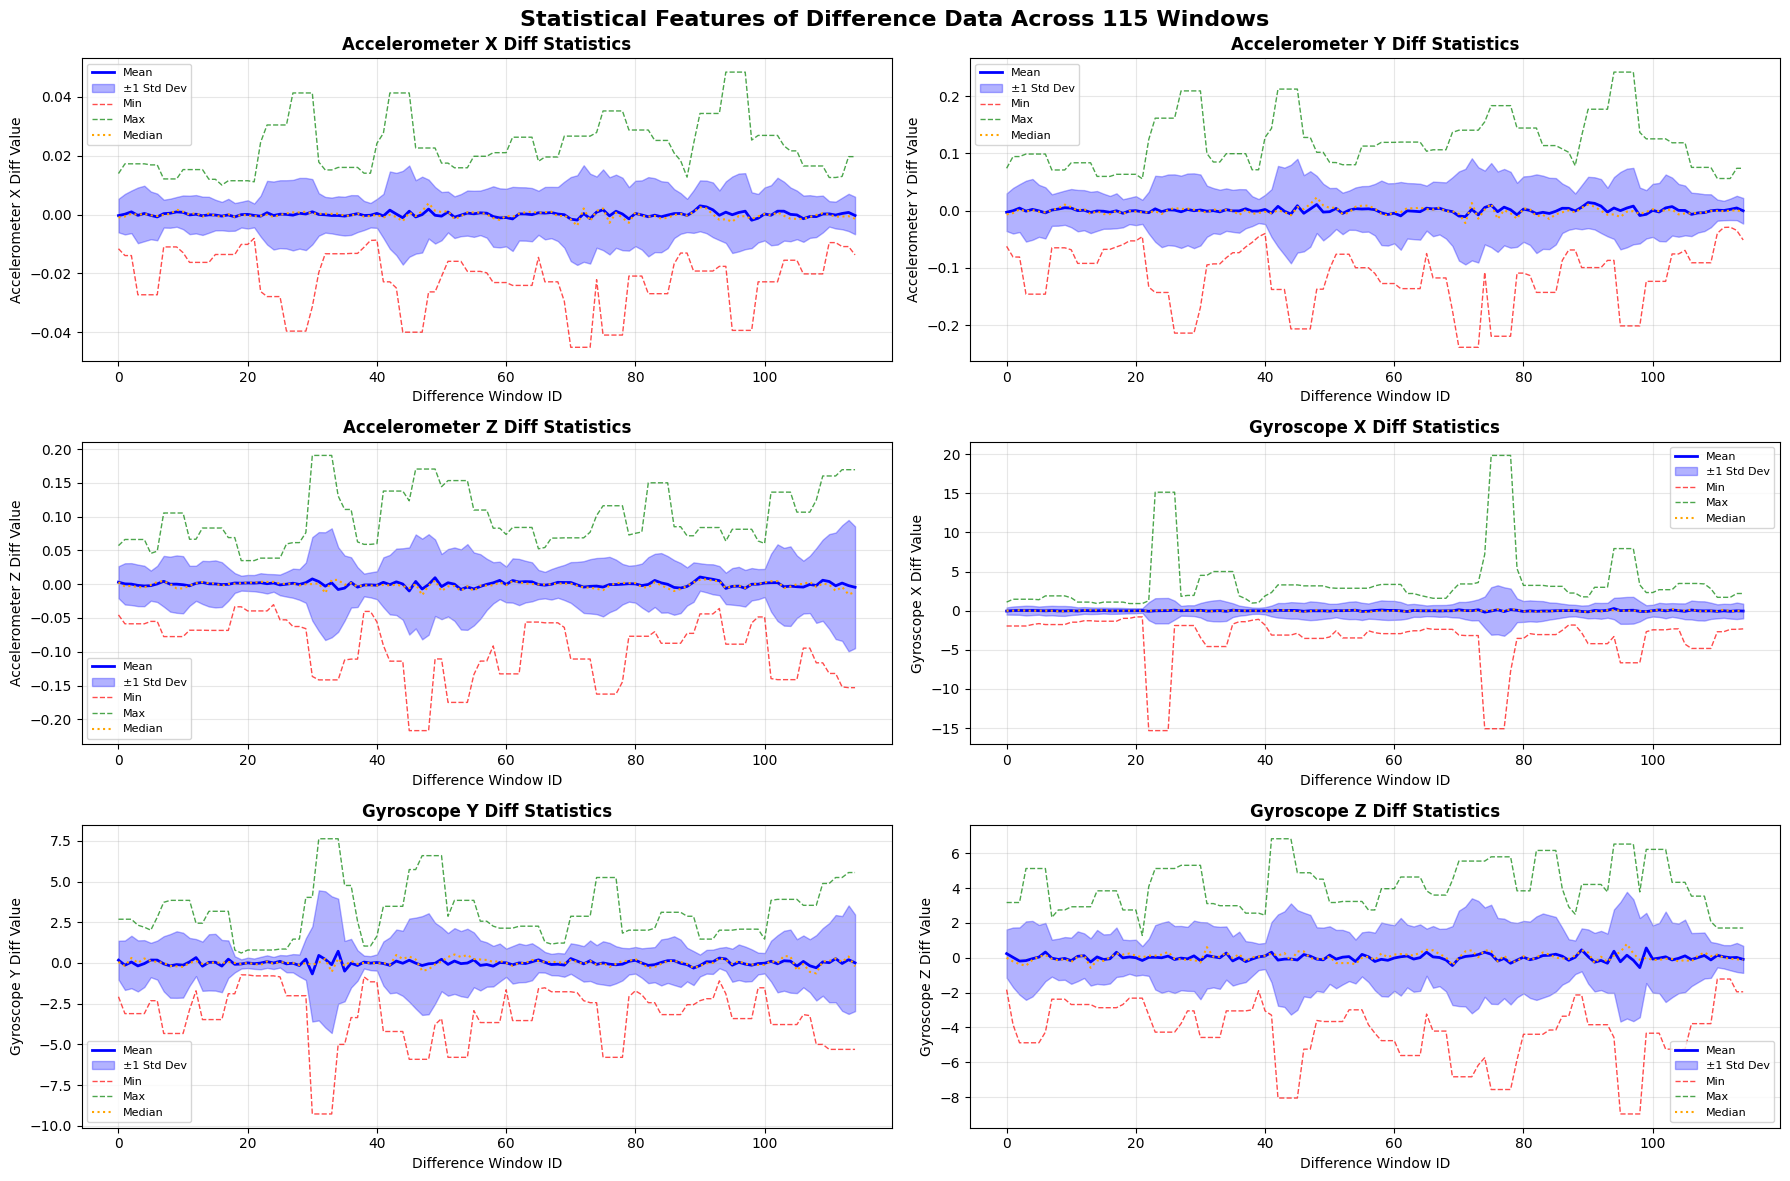

In [12]:
# Plot statistical features for difference data across all windows
fig, axes = plt.subplots(3, 2, figsize=(18, 12))
fig.suptitle('Statistical Features of Difference Data Across 115 Windows', fontsize=16, fontweight='bold')

sensors = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']
sensor_labels = ['Accelerometer X Diff', 'Accelerometer Y Diff', 'Accelerometer Z Diff', 
                 'Gyroscope X Diff', 'Gyroscope Y Diff', 'Gyroscope Z Diff']

for idx, (sensor, label) in enumerate(zip(sensors, sensor_labels)):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    # Plot mean with std as shaded area
    ax.plot(df_stats_diff['diff_window_id'], df_stats_diff[f'{sensor}_mean'], 
            label='Mean', linewidth=2, color='blue')
    ax.fill_between(df_stats_diff['diff_window_id'], 
                     df_stats_diff[f'{sensor}_mean'] - df_stats_diff[f'{sensor}_std'],
                     df_stats_diff[f'{sensor}_mean'] + df_stats_diff[f'{sensor}_std'],
                     alpha=0.3, color='blue', label='±1 Std Dev')
    
    # Plot min and max
    ax.plot(df_stats_diff['diff_window_id'], df_stats_diff[f'{sensor}_min'], 
            label='Min', linewidth=1, linestyle='--', color='red', alpha=0.7)
    ax.plot(df_stats_diff['diff_window_id'], df_stats_diff[f'{sensor}_max'], 
            label='Max', linewidth=1, linestyle='--', color='green', alpha=0.7)
    
    # Plot median
    ax.plot(df_stats_diff['diff_window_id'], df_stats_diff[f'{sensor}_median'], 
            label='Median', linewidth=1.5, linestyle=':', color='orange')
    
    ax.set_xlabel('Difference Window ID', fontsize=10)
    ax.set_ylabel(f'{label} Value', fontsize=10)
    ax.set_title(f'{label} Statistics', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Total samples in df_B: 5992
Window size: 200
Step size: 50
Number of windows created: 116

Windowed dataframe shape: (116, 1203)
Columns: window_id, start_idx, end_idx, + 1200 sensor readings
3D array shape: (116, 200, 6)
Dimensions: (num_windows=116, window_size=200, num_sensors=6)

Array details:
  - Axis 0 (windows/channels): 116 windows
  - Axis 1 (time steps/rows): 200 samples per window
  - Axis 2 (sensor columns): 6 sensors ['ax', 'ay', 'az', 'gx', 'gy', 'gz']

First window, first 5 time steps:
         ax        ay        az        gx        gy        gz
0 -0.925415 -0.069092 -0.360352 -0.122070 -0.671387 -0.793457
1 -0.925415 -0.073364 -0.359009  0.000000 -0.671387 -0.732422
2 -0.925171 -0.072510 -0.359741 -0.305176 -0.732422 -0.854492
3 -0.925171 -0.069946 -0.362427 -0.122070 -0.793457 -0.793457
4 -0.924438 -0.073364 -0.359985  0.122070 -0.732422 -0.671387
Original data_3d_B shape: (116, 200, 6)
Difference data_3d_diff_B shape: (115, 200, 6)
Shape breakdown:
  - Axis 0 (windo

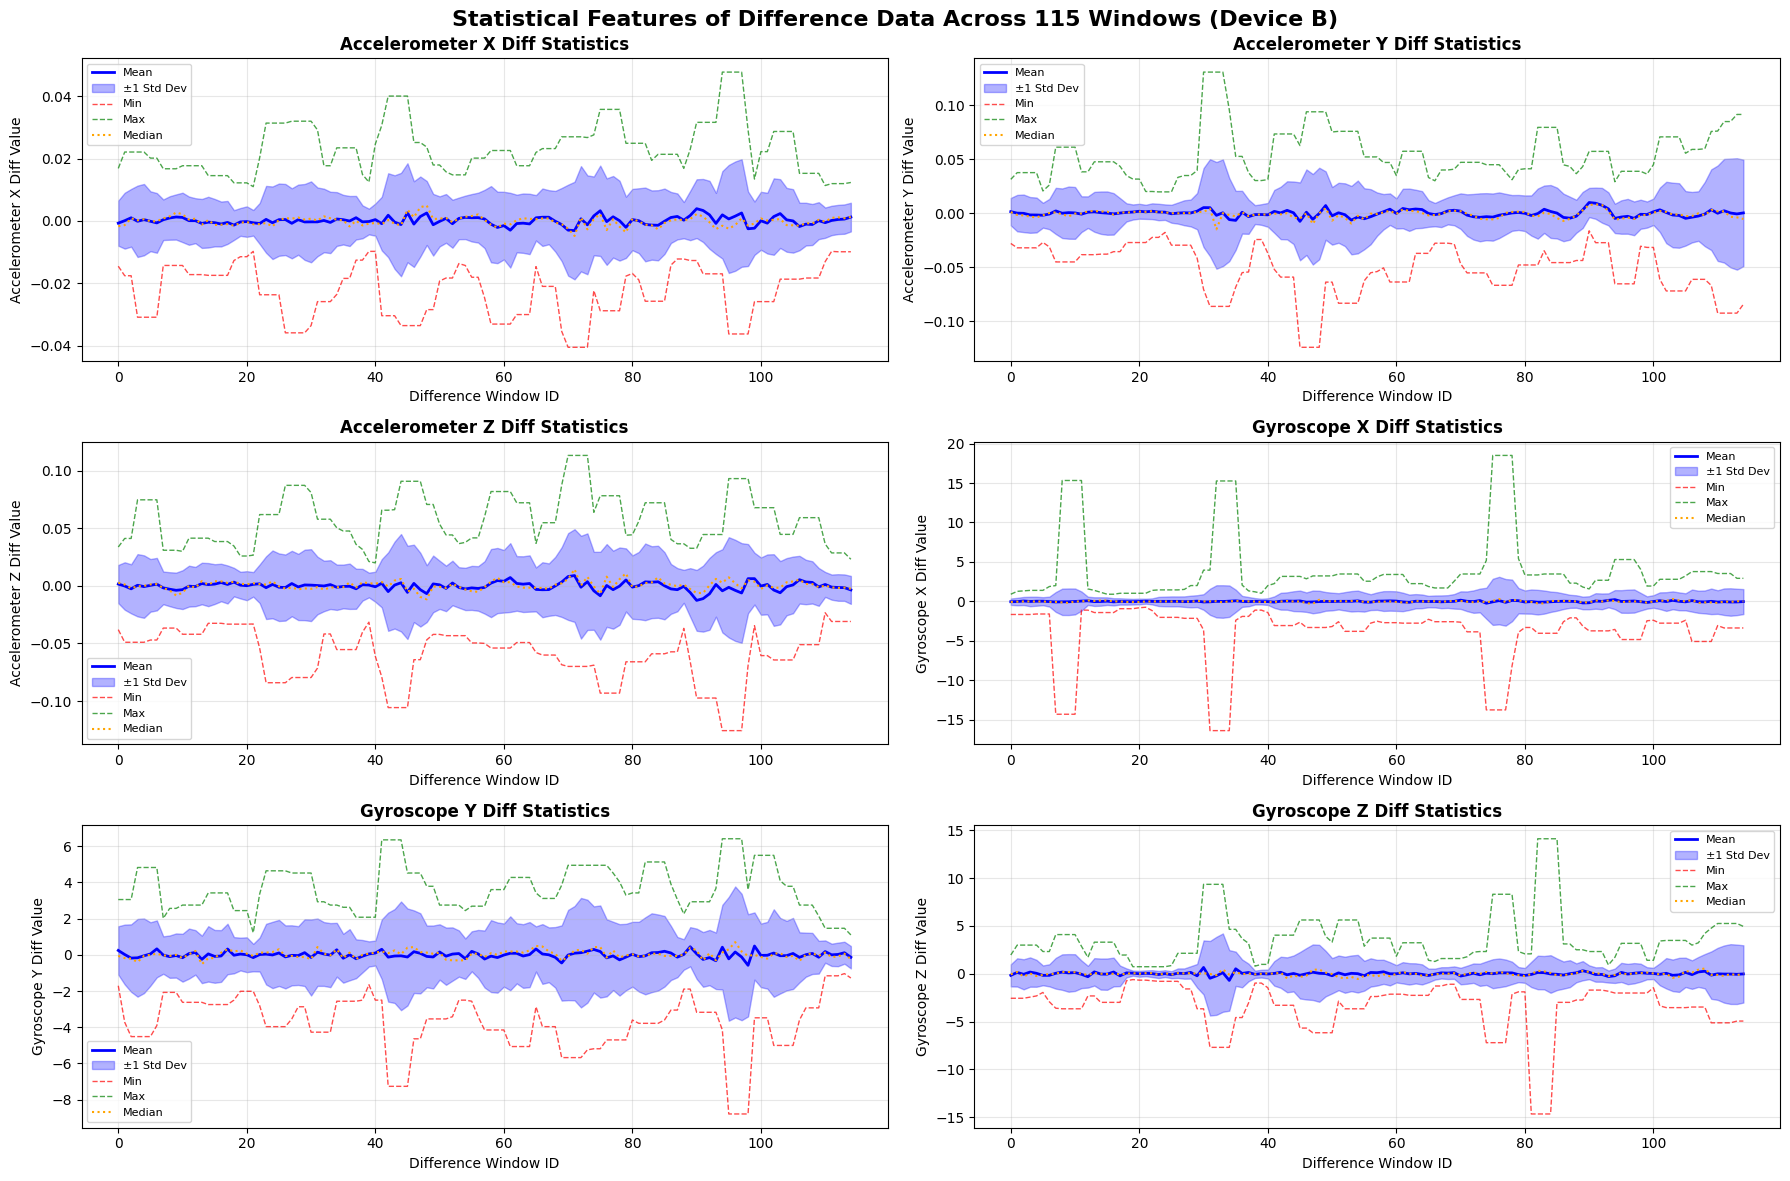

In [13]:
# For B

# Create sliding window dataframe from df_B
# Window size: 200 samples per entry
# Target: < 120 divisions

window_size = 200
total_samples = len(df_B)

# Calculate step size to get approximately <120 divisions
target_divisions = 116
step_size = (total_samples - window_size) // (target_divisions - 1)

print(f"Total samples in df_B: {total_samples}")
print(f"Window size: {window_size}")
print(f"Step size: {step_size}")

# Create sliding windows
windows = []
for i in range(0, total_samples - window_size + 1, step_size):
    window = df_B.iloc[i:i+window_size].copy()
    windows.append(window)
    
print(f"Number of windows created: {len(windows)}")

# Create a list to store each window's data
windowed_data = []
for idx, window in enumerate(windows):
    # Create a dictionary with window metadata and flattened sensor data
    window_dict = {
        'window_id': idx,
        'start_idx': idx * step_size,
        'end_idx': idx * step_size + window_size - 1,
    }
    
    # Add flattened sensor readings
    for col in ['ax', 'ay', 'az', 'gx', 'gy', 'gz']:
        for i, val in enumerate(window[col].values):
            window_dict[f'{col}_{i}'] = val
    
    windowed_data.append(window_dict)

# Create the new dataframe
df_B_windowed = pd.DataFrame(windowed_data)

print(f"\nWindowed dataframe shape: {df_B_windowed.shape}")
print(f"Columns: window_id, start_idx, end_idx, + {6 * window_size} sensor readings")
df_B_windowed.head()


# Create 3D array: (num_windows, window_size, num_sensors)
# Shape: (116, 200, 6)
# Dimensions: [window_id, time_step, sensor_channel]

sensor_columns = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']
num_windows = len(windows)
num_sensors = len(sensor_columns)

# Initialize 3D array
data_3d_B = np.zeros((num_windows, window_size, num_sensors))

# Fill the 3D array
for window_idx, window in enumerate(windows):
    for sensor_idx, sensor in enumerate(sensor_columns):
        data_3d_B[window_idx, :, sensor_idx] = window[sensor].values

print(f"3D array shape: {data_3d_B.shape}")
print(f"Dimensions: (num_windows={num_windows}, window_size={window_size}, num_sensors={num_sensors})")
print(f"\nArray details:")
print(f"  - Axis 0 (windows/channels): {data_3d_B.shape[0]} windows")
print(f"  - Axis 1 (time steps/rows): {data_3d_B.shape[1]} samples per window")
print(f"  - Axis 2 (sensor columns): {data_3d_B.shape[2]} sensors {sensor_columns}")
print(f"\nFirst window, first 5 time steps:")
print(pd.DataFrame(data_3d_B[0, :5, :], columns=sensor_columns))


# Calculate difference between consecutive windows using data_3d_B
# For each window, compute: window[i+1] - window[i]
# Shape: (115, 200, 6) - one less window since computing differences

# Calculate differences between consecutive windows
data_3d_diff_B = np.diff(data_3d_B, axis=0)

print(f"Original data_3d_B shape: {data_3d_B.shape}")
print(f"Difference data_3d_diff_B shape: {data_3d_diff_B.shape}")
print(f"Shape breakdown:")
print(f"  - Axis 0 (window differences): {data_3d_diff_B.shape[0]} (115 = 116 - 1)")
print(f"  - Axis 1 (time steps): {data_3d_diff_B.shape[1]} samples per window")
print(f"  - Axis 2 (sensors): {data_3d_diff_B.shape[2]} sensors {sensor_columns}")

print(f"\nFirst difference window, first 5 time steps:")
print(pd.DataFrame(data_3d_diff_B[0, :5, :], columns=sensor_columns))


# Calculate statistical features on the difference data
# For each of the 115 difference windows, compute statistics across the 200 time steps

num_diff_windows = data_3d_diff_B.shape[0]

# Initialize dictionary to store statistics for difference data
stats_diff_dict = {
    'diff_window_id': []
}

# Use the same statistical functions
stat_functions = {
    'mean': np.mean,
    'std': np.std,
    'min': np.min,
    'max': np.max,
    'median': np.median,
    'q25': lambda x: np.percentile(x, 25),
    'q75': lambda x: np.percentile(x, 75)
}

# Initialize columns for each sensor and statistic
for sensor in sensor_columns:
    for stat_name in stat_functions.keys():
        stats_diff_dict[f'{sensor}_{stat_name}'] = []

# Compute statistics for each difference window
for window_idx in range(num_diff_windows):
    stats_diff_dict['diff_window_id'].append(window_idx)
    
    # For each sensor
    for sensor_idx, sensor in enumerate(sensor_columns):
        # Extract the time series for this difference window and sensor
        time_series = data_3d_diff_B[window_idx, :, sensor_idx]
        
        # Compute each statistic
        for stat_name, stat_func in stat_functions.items():
            value = stat_func(time_series)
            stats_diff_dict[f'{sensor}_{stat_name}'].append(value)

# Create DataFrame with difference statistics
df_stats_diff_B = pd.DataFrame(stats_diff_dict)

print(f"Difference Statistics DataFrame shape: {df_stats_diff_B.shape}")
print(f"Rows: {df_stats_diff_B.shape[0]} difference windows")
print(f"Columns: {df_stats_diff_B.shape[1]} features (diff_window_id + {len(sensor_columns)} sensors × {len(stat_functions)} statistics)")
print(f"\nFirst 5 difference windows statistics:")
df_stats_diff_B.head()

# Plot statistical features for difference data across all windows
fig, axes = plt.subplots(3, 2, figsize=(18, 12))
fig.suptitle('Statistical Features of Difference Data Across 115 Windows (Device B)', fontsize=16, fontweight='bold')

sensors = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']
sensor_labels = ['Accelerometer X Diff', 'Accelerometer Y Diff', 'Accelerometer Z Diff', 
                 'Gyroscope X Diff', 'Gyroscope Y Diff', 'Gyroscope Z Diff']

for idx, (sensor, label) in enumerate(zip(sensors, sensor_labels)):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    # Plot mean with std as shaded area
    ax.plot(df_stats_diff_B['diff_window_id'], df_stats_diff_B[f'{sensor}_mean'], 
            label='Mean', linewidth=2, color='blue')
    ax.fill_between(df_stats_diff_B['diff_window_id'], 
                     df_stats_diff_B[f'{sensor}_mean'] - df_stats_diff_B[f'{sensor}_std'],
                     df_stats_diff_B[f'{sensor}_mean'] + df_stats_diff_B[f'{sensor}_std'],
                     alpha=0.3, color='blue', label='±1 Std Dev')
    
    # Plot min and max
    ax.plot(df_stats_diff_B['diff_window_id'], df_stats_diff_B[f'{sensor}_min'], 
            label='Min', linewidth=1, linestyle='--', color='red', alpha=0.7)
    ax.plot(df_stats_diff_B['diff_window_id'], df_stats_diff_B[f'{sensor}_max'], 
            label='Max', linewidth=1, linestyle='--', color='green', alpha=0.7)
    
    # Plot median
    ax.plot(df_stats_diff_B['diff_window_id'], df_stats_diff_B[f'{sensor}_median'], 
            label='Median', linewidth=1.5, linestyle=':', color='orange')
    
    ax.set_xlabel('Difference Window ID', fontsize=10)
    ax.set_ylabel(f'{label} Value', fontsize=10)
    ax.set_title(f'{label} Statistics', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# Take out max, min, and mean of window diff for both devices and save to CSV
# Add device type column and activity label column as riding

sensor_columns = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']

# Select columns for Device A
selected_columns = ['diff_window_id']
for sensor in sensor_columns:
    for stat in ['max', 'min', 'mean']:
        selected_columns.append(f'{sensor}_{stat}')

df_selected_A = df_stats_diff[selected_columns].copy()
df_selected_B = df_stats_diff_B[selected_columns].copy()

# Add device type column
df_selected_A['device'] = 'A'
df_selected_B['device'] = 'B'

# Add activity label column
df_selected_A['activity'] = 'riding'
df_selected_B['activity'] = 'riding'

# Combine both devices
df_combined = pd.concat([df_selected_A, df_selected_B], ignore_index=True)

# Save to CSV
output_file = 'riding_window_diff_stats.csv'
df_combined.to_csv(output_file, index=False)

print(f"Combined data shape: {df_combined.shape}")
print(f"Saved to: {output_file}")
print(f"\nDevice A rows: {len(df_selected_A)}")
print(f"Device B rows: {len(df_selected_B)}")
print(f"Total rows: {len(df_combined)}")
print(f"\nColumns: {df_combined.columns.tolist()}")
print(f"\nFirst few rows:")
df_combined.head(10)


Combined data shape: (230, 21)
Saved to: riding_window_diff_stats.csv

Device A rows: 115
Device B rows: 115
Total rows: 230

Columns: ['diff_window_id', 'ax_max', 'ax_min', 'ax_mean', 'ay_max', 'ay_min', 'ay_mean', 'az_max', 'az_min', 'az_mean', 'gx_max', 'gx_min', 'gx_mean', 'gy_max', 'gy_min', 'gy_mean', 'gz_max', 'gz_min', 'gz_mean', 'device', 'activity']

First few rows:


,diff_window_id,ax_max,ax_min,ax_mean,ay_max,ay_min,ay_mean,az_max,az_min,az_mean,...,gx_min,gx_mean,gy_max,gy_min,gy_mean,gz_max,gz_min,gz_mean,device,activity
0,0,0.013916,-0.011597,-0.000347,0.073853,-0.062378,-0.002838,0.057129,-0.045410,0.002910,...,-1.953126,-0.042419,2.685547,-2.075196,0.172119,3.173828,-1.831054,0.238953,A,riding
1,1,0.017212,-0.013916,0.000126,0.094360,-0.081054,-0.000214,0.066162,-0.058594,0.000488,...,-1.953126,0.013428,2.685547,-3.112793,-0.138245,3.173829,-3.845215,0.021667,A,riding
2,2,0.017212,-0.013916,0.000919,0.094360,-0.081054,0.004333,0.066162,-0.058594,0.000138,...,-1.953126,0.032043,2.685547,-3.112793,0.057983,3.173829,-4.882814,-0.189209,A,riding
3,3,0.017212,-0.027222,-0.000272,0.098755,-0.145874,-0.000952,0.066162,-0.058594,-0.001726,...,-1.953126,0.018005,2.319336,-3.112793,-0.182190,5.126953,-4.882814,-0.163879,A,riding
4,4,0.017212,-0.027222,0.000371,0.098755,-0.145874,0.002120,0.066162,-0.058594,-0.002625,...,-1.770021,0.030823,2.197267,-3.112793,-0.039062,5.126953,-4.882814,-0.052795,A,riding
5,5,0.016846,-0.027222,-0.000284,0.098755,-0.145874,-0.000394,0.045532,-0.055053,-0.002139,...,-1.647949,0.008850,2.014160,-2.319336,0.178833,5.126953,-4.882814,0.038452,A,riding
6,6,0.016846,-0.027222,-0.000812,0.098755,-0.145874,-0.003943,0.048951,-0.055053,0.000430,...,-1.770020,-0.016479,2.807617,-2.319336,0.175476,5.126953,-4.272461,0.327148,A,riding
7,7,0.012085,-0.010987,0.000309,0.070923,-0.064942,0.000906,0.105346,-0.077515,0.004314,...,-1.770020,0.021362,3.723145,-4.333497,-0.052490,2.319336,-2.380371,-0.021667,A,riding
8,8,0.012085,-0.010987,0.000450,0.070923,-0.064942,0.002681,0.105346,-0.077515,0.000037,...,-1.770020,-0.022278,3.845216,-4.333497,-0.181580,2.746582,-2.380371,-0.094910,A,riding
9,9,0.012085,-0.010987,0.000905,0.070923,-0.064942,0.005025,0.105346,-0.077515,0.000113,...,-1.770020,-0.028381,3.845216,-4.333497,-0.099487,2.746582,-2.380371,-0.037231,A,riding
